# ✂️ Stage 4 · Segmenting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DreamEmulator/rtu-computer-vision/blob/main/03_image-segmentation/segmenting.ipynb)

**Topic of the week:** Image Segmentation · **Lecture:** Tue 29.09 · **Startup question:** *Which pixels belong to the drip chamber, and which are just background?*

Segmentation splits a frame into foreground and background: first a threshold turns brightness into a yes/no mask, then morphology repairs the mask, and contours turn blobs into objects we can measure, fill or crop.

| In the CI-pipeline | |
|---|---|
| Why? | [`README.md`](README.md) |
| How? — the 🎛️ tinker zone | [`segmenting_threshold/action.yaml`](segmenting_threshold/action.yaml) |
| What? — Step 0 to 3 | [`Todo_Segmenting.md`](Todo_Segmenting.md) |
| 🧪 Recipe — the maths CI runs | [`segmenting_threshold/recipe.py`](segmenting_threshold/recipe.py) |
| 🧪 Sandboxes — one sub-step, one frame | [`segmenting_threshold/sandboxes/`](segmenting_threshold/sandboxes/) |

This notebook imports the **same functions** CI runs, with the values from your tinker zone. Explore here, then commit your choice to the tinker zone on a branch and let CI prove it.

In [1]:
# ⚙️ Setup — works locally, in Codespaces and in Colab (Colab already has every library we need)
import os, subprocess, sys
REPO = "DreamEmulator/rtu-computer-vision"  # filled in automatically in your own copy of the template
here = os.getcwd()
while not os.path.exists("run_pipeline.py") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                      # notebooks live in the topic folders; the pipeline root is up
if not os.path.exists("run_pipeline.py"):   # Colab: fetch the repository first
    os.chdir(here)
    if not os.path.exists("repo"):
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", "repo"], check=True)
    os.chdir("repo")
sys.path.insert(0, os.getcwd())

import cv2, json, numpy as np, matplotlib.pyplot as plt
from stages.common import load_images, to_luma
from stages.nb import prepare, run_stage, show
%matplotlib inline

✔ Stages up to 'improving' ran with your tinker-zone values


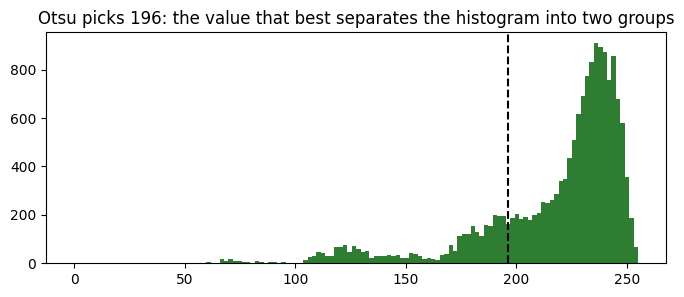

In [2]:
cfg = prepare("improving")
from stages.s4_segmenting import threshold, morphology, keep_contours, apply, overlay
s3 = load_images("improving"); sp = s3.color_space; seg = cfg["segmenting"]
i = next(k for k, r in enumerate(s3.rows) if r["label"] == "drop" and r["split"] == "test")
img = s3.images[i]; gray = to_luma(img, sp)
t, _ = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.figure(figsize=(8, 3)); plt.hist(gray.ravel(), 128, range=(0, 255), color="#2e7d32"); plt.axvline(t, c="k", ls="--")
plt.title(f"Otsu picks {t:.0f}: the value that best separates the histogram into two groups"); plt.show()

## One threshold or many?

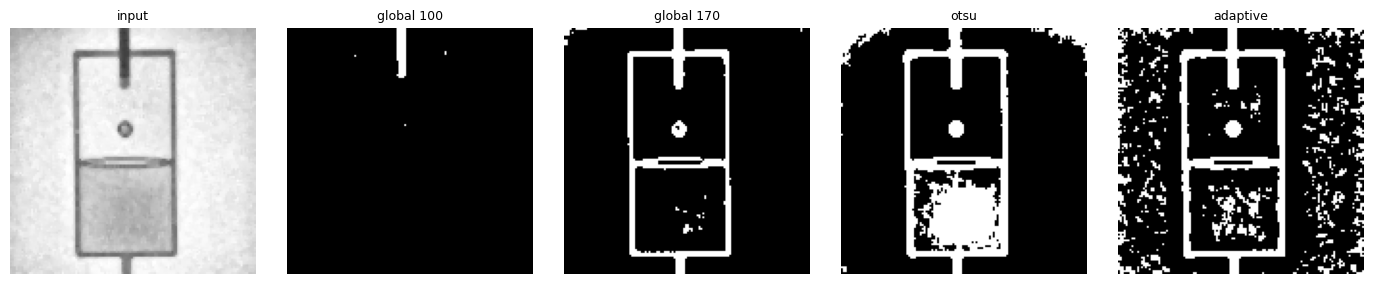

In [3]:
tries = {"global 100": {**seg, "threshold": "global", "global_value": 100},
         "global 170": {**seg, "threshold": "global", "global_value": 170},
         "otsu": {**seg, "threshold": "otsu"}, "adaptive": {**seg, "threshold": "adaptive"}}
show([gray] + [threshold(gray, c)[0] for c in tries.values()], ["input"] + list(tries), size=2.8)

The backlight is uneven (vignetting), so a single threshold for the whole frame struggles in the corners. Same comparison over several test frames:

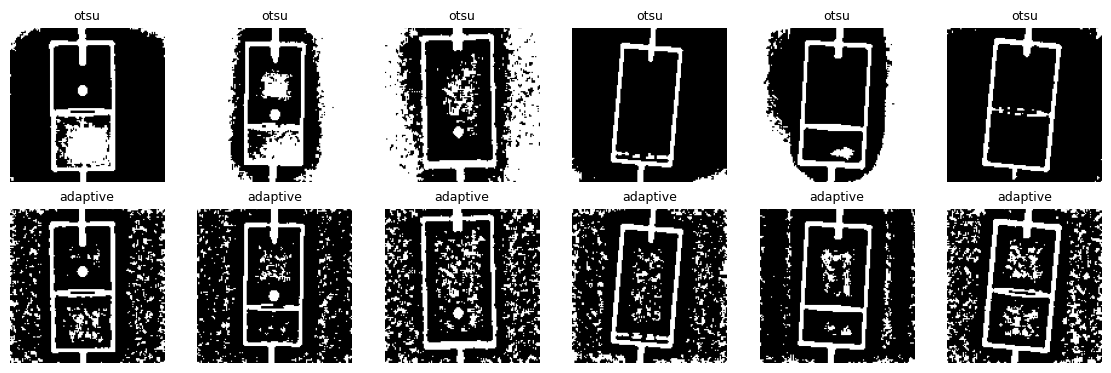

In [4]:
idx = [k for k, r in enumerate(s3.rows) if r["split"] == "test"][::15][:6]
frames = [to_luma(s3.images[k], sp) for k in idx]
show([threshold(f, {**seg, "threshold": "otsu"})[0] for f in frames] +
     [threshold(f, {**seg, "threshold": "adaptive"})[0] for f in frames],
     ["otsu"] * 6 + ["adaptive"] * 6, cols=6, size=1.9)

## Morphology: repairing the mask

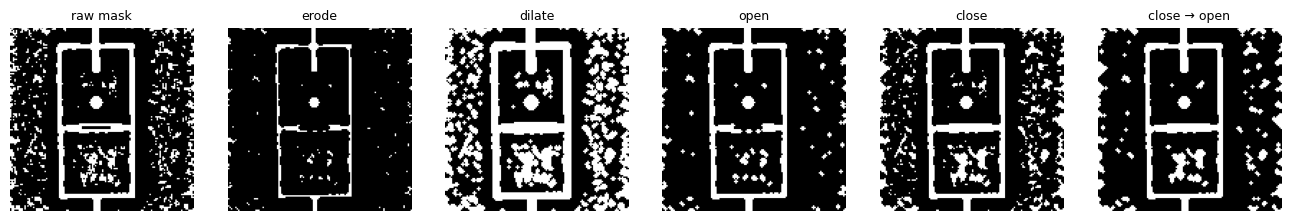

In [5]:
mask, _ = threshold(gray, seg)
ops = {"raw mask": [], "erode": ["erode"], "dilate": ["dilate"], "open": ["open"], "close": ["close"], "close → open": ["close", "open"]}
show([morphology(mask, {**seg, "morphology": o}) for o in ops.values()], list(ops), cols=6, size=2.2)

## Contours: from blobs to objects

150 contours; largest areas: [5720, 64, 48, 38, 35, 35]


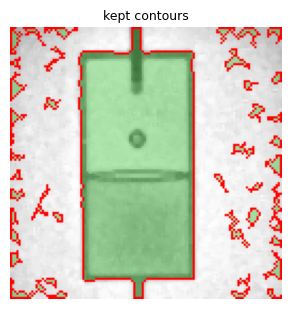

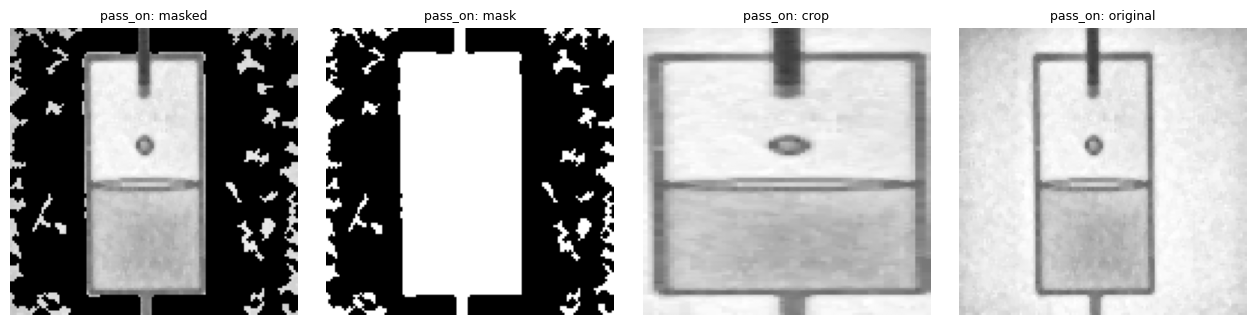

In [6]:
m = morphology(mask, seg)
contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(len(contours), "contours; largest areas:", [round(a) for a in sorted(map(cv2.contourArea, contours), reverse=True)[:6]])
final, kept = keep_contours(m, seg)
show([overlay(img, final, kept, sp)], ["kept contours"], color_space="bgr", size=3.2)
show([apply(img, final, kept, h) for h in ("masked", "mask", "crop", "original")],
     ["pass_on: masked", "pass_on: mask", "pass_on: crop", "pass_on: original"], color_space=sp, size=3.2)

## 🧪 Your turn
1. Switch to `threshold: otsu` and look at the stage 4 preview in CI. Which frames go wrong, and why there?
2. `fill_holes: false`: what's left of the chamber? What does stage 6 think of that?
3. `pass_on: original` is an **ablation**: it keeps the stage but ignores its result. If accuracy stays the same, what does that say about the stage? Try `crop` next.

## 🚀 Ship your choice

1. Create a branch: `experiment/<what-you-change>`
2. Change **one** value in the 🎛️ TINKER ZONE of this topic's `action.yaml`
3. Push and open a pull request. The PR template asks for your hypothesis and result.
4. Compare the 🎤 Demo Day table of your PR with the one on `main`. Better? Merge. Not better? Close it and write down why — that's R&D too.